# RQ029 v2 paper-claim parity audit

## tl;dr

**POINT_ESTIMATES_EXACT / INTERVALS_PARTIAL / RAW_EMERGENT_MISMATCH / FULL_DISTRIBUTION_NOT_IDENTIFIABLE.**

The v2 calibrated layer reproduces the manuscript's hard counts and point estimates. Four of five synthetic confidence intervals are within the predeclared tolerance but not equal to the printed endpoints; the alpha-90 run-bootstrap interval is a clear mismatch. Raw trajectory-derived TTC/counterpart outcomes do not reproduce the paper points. Exact full-distribution matching is not identifiable from the available aggregate human record and is not claimed.

## Context & Methods

This notebook compares the current paper record at commit `938b77669663` against RQ029 v2. It keeps three layers separate:

1. **Paper target:** verified real-human aggregate values.
2. **Calibrated synthetic layer:** explicitly constrained fields used for paper-claim compatibility tests.
3. **Raw synthetic layer:** outcomes derived from the generated trajectories and unchanged Shanghai background replay.

### Key assumptions

- The paper's rounded intervals constrain a synthetic engineering proxy; they do not identify the true run/case mapping or covariance.
- Bootstrap definitions, sorting, clusters, draws and seeds are imported from the current validator instead of reimplemented.
- This notebook does not read RQ007 held-out data or RQ014 blinded fields.

In [1]:
from pathlib import Path
import copy
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pipelines.simulation.calibrate_rq029_paper_v2 import _paper_metrics
from pipelines.simulation.validate_rq029_paper_v2 import _intervals_from_detail

REPO_ROOT = Path.cwd()
assert (REPO_ROOT / 'START_HERE.md').is_file(), REPO_ROOT

DATA_ROOT = REPO_ROOT / 'data/derived/rq029_human_synthetic_microdata/v2_paper_aligned'
REPORT_ROOT = REPO_ROOT / 'reports/studies/RQ029_human_synthetic_microdata/RQ029_4_paper_claim_parity_audit_20260904'
REPORT_ROOT.mkdir(parents=True, exist_ok=True)
(REPORT_ROOT / 'figures').mkdir(exist_ok=True)

base_targets = json.loads((REPO_ROOT / 'reports/plans/RQ029_human_statistical_targets_v1.json').read_text())
paper_targets = json.loads((REPO_ROOT / 'reports/plans/RQ029_paper_record_targets_v2.json').read_text())
av_reference = json.loads((REPO_ROOT / '.codex-fleet/rq022-matched-scenario/work/T1_target_figure/av_reference_values.json').read_text())
manifest = json.loads((DATA_ROOT / 'manifest.json').read_text())

assert paper_targets['paper_commit_observed'] == '938b77669663'
assert manifest['data_status'] == 'SYNTHETIC_NOT_OBSERVED'
print('paper commit:', paper_targets['paper_commit_observed'])
print('synthetic status:', manifest['data_status'])
print('claim status:', manifest['paper_claim_match_status'])

paper commit: 938b77669663
synthetic status: SYNTHETIC_NOT_OBSERVED
claim status: POINT_ESTIMATES_EXACT_INTERVALS_PARTIAL


## Data

The intended grain is 300 `driver_id × scenario_id` runs. Candidate metrics are moment-level; counterpart metrics are selected anchor windows clustered by 186 synthetic case IDs.

In [2]:
candidates = pd.read_parquet(DATA_ROOT / 'tables/candidate_moments.parquet')
counterpart = pd.read_parquet(DATA_ROOT / 'tables/counterpart_windows.parquet')
unit = pd.read_csv(DATA_ROOT / 'tables/per_unit_counts.csv')
continuity = json.loads((REPO_ROOT / 'reports/studies/RQ029_human_synthetic_microdata/RQ029_3_trajectory_continuity_audit_20260904/summary.json').read_text())

both = candidates.status.eq('OK') & candidates.mechanism2_gate_ok
assert len(candidates) == 78_903
assert int(candidates.status.eq('OK').sum()) == 40_993
assert int(both.sum()) == 15_598
assert unit.run_id.nunique() == 300
assert counterpart.synthetic_case_id.nunique() == 186

print({'candidate_rows': len(candidates), 'gate1': int(candidates.status.eq('OK').sum()), 'both': int(both.sum()), 'runs': int(unit.run_id.nunique()), 'synthetic_cases': int(counterpart.synthetic_case_id.nunique())})

{'candidate_rows': 78903, 'gate1': 40993, 'both': 15598, 'runs': 300, 'synthetic_cases': 186}


## Results

### Recompute paper metrics, calibrated points and raw diagnostics

In [3]:
intervals = _intervals_from_detail(candidates, counterpart, unit)

v2_human_targets = copy.deepcopy(base_targets)
for alpha in ('80', '90', '95'):
    bands = candidates.loc[both, f'band_{alpha}']
    v2_human_targets['flag_counts'][alpha] = {
        'n_below': int(bands.eq('lower').sum()),
        'n_above': int(bands.eq('upper').sum()),
        'n_inside': int(bands.eq('inside').sum()),
        'n_total': int(len(bands)),
    }
v2_human_targets['per_scenario_alpha90'] = {}
for scenario in base_targets['scenarios']:
    frame = candidates[both & candidates.scenario_id.eq(scenario)]
    v2_human_targets['per_scenario_alpha90'][scenario] = {
        'n_both': int(len(frame)),
        'n_flagged': int(frame.band_90.isin(['lower', 'upper']).sum()),
    }
paper_metrics = _paper_metrics(v2_human_targets, av_reference)

ego = {}
for band in ('lower', 'inside'):
    selected = candidates[candidates.band_90.eq(band) & candidates.future_min_ttc_s_calibrated.notna()]
    calibrated = selected.future_min_ttc_s_calibrated.dropna().to_numpy(float)
    raw = selected.future_min_ttc_raw_s.dropna().to_numpy(float)
    ego[band] = {
        'cal_n': len(calibrated),
        'raw_n': len(raw),
        'cal_q': np.quantile(calibrated, [0.25, 0.50, 0.75]),
        'raw_q': np.quantile(raw, [0.25, 0.50, 0.75]),
        'cal_tail_num': int((calibrated < 2.0).sum()),
        'raw_tail_num': int((raw < 2.0).sum()),
    }

cp = {}
for band in ('lower', 'inside'):
    frame = counterpart[counterpart.band_90.eq(band)]
    cp[band] = {
        'n': len(frame),
        'cal_drop': float(frame.anchor_speed_drop_kmh_calibrated.median()),
        'raw_drop': float(frame.anchor_speed_drop_kmh_raw.median()),
        'cal_range': float(frame.window_speed_range_kmh_calibrated.median()),
        'raw_range': float(frame.window_speed_range_kmh_raw.median()),
        'cal_brake_num': int(frame.n_frames_lt_m3_calibrated.sum()),
        'cal_brake_den': int(frame.n_frames_total_calibrated.sum()),
        'raw_brake_num': int(frame.n_frames_lt_m3_raw.sum()),
        'raw_brake_den': int(frame.n_frames_total_raw.sum()),
    }

print('intervals:', intervals)
print('raw TTC ratios:', ego['lower']['raw_q'] / ego['inside']['raw_q'])
print('calibrated TTC ratios:', ego['lower']['cal_q'] / ego['inside']['cal_q'])

intervals: {'alpha90': [0.04221849164014768, 0.05850213316040428], 'ego_ttc': [-0.049066921422966564, -0.005454805708783488], 'speed_drop': [1.2454267798541236, 2.896203036797316], 'speed_range': [1.1979707095065384, 1.8473243377809576], 'braking': [-0.04407604629100153, -0.006309908840301126]}
raw TTC ratios: [1.24287835 0.77411889 0.49085237]
calibrated TTC ratios: [0.92857143 0.81264637 0.70410816]


In [4]:
records = []

def add(category, metric, target, calibrated, raw, status, raw_status='', unit_denominator='', cluster_draws='', note=''):
    records.append({
        'category': category,
        'metric': metric,
        'paper_target': json.dumps(target, ensure_ascii=False),
        'v2_calibrated': json.dumps(calibrated, ensure_ascii=False),
        'v2_raw': json.dumps(raw, ensure_ascii=False),
        'status': status,
        'raw_status': raw_status,
        'unit_denominator': unit_denominator,
        'cluster_draws': cluster_draws,
        'note': note,
    })

add('structure', 'drivers_scenarios_runs_missing', [20,15,300,0], [candidates.driver_id.nunique(), candidates.scenario_id.nunique(), unit.run_id.nunique(), 0], None, 'EXACT', unit_denominator='run')
add('gates', 'candidate_gate1_both', [78903,40993,15598], [len(candidates), int(candidates.status.eq('OK').sum()), int(both.sum())], None, 'EXACT', unit_denominator='moment')
for alpha in ('80','90','95'):
    observed = v2_human_targets['flag_counts'][alpha]
    add('flags', f'alpha{alpha}_below_above_inside_total', base_targets['flag_counts'][alpha], observed, None, 'EXACT', unit_denominator='judgeable moment')

human_rate = (v2_human_targets['flag_counts']['90']['n_below'] + v2_human_targets['flag_counts']['90']['n_above']) / v2_human_targets['flag_counts']['90']['n_total']
add('flags', 'alpha90_rate', paper_targets['human_alpha90']['rate'], human_rate, None, 'EXACT', unit_denominator='786/15,598 moments')
add('flags', 'alpha90_scenario_range', paper_targets['human_alpha90']['scenario_rate_range_rounded'], paper_metrics['human_scenario_rate_range'], None, 'WITHIN_PRINTED_PRECISION', unit_denominator='15 scenarios')
add('flags', 'alpha90_run_bootstrap_ci95', base_targets['flag_rate_ci95_alpha90_target'], intervals['alpha90'], None, 'CLEAR_MISMATCH', unit_denominator='300 driver-scenario runs', cluster_draws='run_id; B=1,000; canonical stable seed')

add('arm_comparison', 'av_to_human_ratio', paper_targets['automated_to_human']['display_ratio'], paper_metrics['moment_weighted_ratio'], None, 'WITHIN_PRINTED_PRECISION', unit_denominator='1,388/14,099 vs 786/15,598')
add('arm_comparison', 'av_to_human_scenario_bootstrap_ci95', paper_targets['automated_to_human']['scenario_bootstrap_ci95_rounded'], paper_metrics['scenario_bootstrap_ci95'], None, 'WITHIN_PRINTED_PRECISION', unit_denominator='15 scenarios', cluster_draws='scenario; B=20,000; seed=20260820')
add('arm_comparison', 'scenarios_av_higher', 15, paper_metrics['scenarios_av_higher'], None, 'EXACT', unit_denominator='15 scenarios')

q_names = ['q25','q50','q75']
for index, name in enumerate(q_names):
    target_ratio = base_targets['signature']['ego_ttc']['lower'][name] / base_targets['signature']['ego_ttc']['inside'][name]
    cal_ratio = float(ego['lower']['cal_q'][index] / ego['inside']['cal_q'][index])
    raw_ratio = float(ego['lower']['raw_q'][index] / ego['inside']['raw_q'][index])
    add('ego_ttc', f'{name}_lower_to_inside_ratio', target_ratio, cal_ratio, raw_ratio, 'EXACT', 'CLEAR_MISMATCH', unit_denominator=f"{ego['lower']['cal_n']}/{ego['inside']['cal_n']} calibrated moments", note='Paper point match exists only on calibrated field.')
add('ego_ttc', 'finite_n_lower_inside', [389,13568], [ego['lower']['cal_n'],ego['inside']['cal_n']], [ego['lower']['raw_n'],ego['inside']['raw_n']], 'EXACT', 'CLEAR_MISMATCH', unit_denominator='selected moments')

target_tail_diff = base_targets['signature']['ego_ttc']['lower']['lt2_num']/389 - base_targets['signature']['ego_ttc']['inside']['lt2_num']/13568
cal_tail_diff = ego['lower']['cal_tail_num']/ego['lower']['cal_n'] - ego['inside']['cal_tail_num']/ego['inside']['cal_n']
raw_tail_diff = ego['lower']['raw_tail_num']/ego['lower']['raw_n'] - ego['inside']['raw_tail_num']/ego['inside']['raw_n']
add('ego_ttc', 'ttc_lt2_share_difference', target_tail_diff, cal_tail_diff, raw_tail_diff, 'EXACT', 'CLEAR_MISMATCH', unit_denominator='13/389 vs 765/13,568')
add('ego_ttc', 'ttc_lt2_difference_ci95', base_targets['signature']['ego_ttc']['lt2_diff_ci95_target'], intervals['ego_ttc'], None, 'WITHIN_TOLERANCE_NOT_EXACT', unit_denominator='run-clustered selected moments', cluster_draws='run_id; B=1,000')

cp_target = base_targets['signature']['counterpart']
cal_drop_ratio = cp['lower']['cal_drop']/cp['inside']['cal_drop']
raw_drop_ratio = cp['lower']['raw_drop']/cp['inside']['raw_drop']
cal_range_ratio = cp['lower']['cal_range']/cp['inside']['cal_range']
raw_range_ratio = cp['lower']['raw_range']/cp['inside']['raw_range']
cal_brake_diff = cp['lower']['cal_brake_num']/cp['lower']['cal_brake_den'] - cp['inside']['cal_brake_num']/cp['inside']['cal_brake_den']
raw_brake_diff = cp['lower']['raw_brake_num']/cp['lower']['raw_brake_den'] - cp['inside']['raw_brake_num']/cp['inside']['raw_brake_den']
add('counterpart', 'n_lower_inside_cases', [367,12461,186], [cp['lower']['n'],cp['inside']['n'],counterpart.synthetic_case_id.nunique()], None, 'EXACT', unit_denominator='anchor/case')
add('counterpart', 'speed_drop_ratio', cp_target['speed_drop_median_lower_kmh']/cp_target['speed_drop_median_inside_kmh'], cal_drop_ratio, raw_drop_ratio, 'EXACT', 'CLEAR_MISMATCH', unit_denominator='367/12,461 anchors')
add('counterpart', 'speed_drop_ratio_ci95', cp_target['speed_drop_ratio_ci95_target'], intervals['speed_drop'], None, 'WITHIN_TOLERANCE_NOT_EXACT', cluster_draws='synthetic_case_id; B=2,000')
add('counterpart', 'speed_range_ratio', cp_target['speed_range_median_lower_kmh']/cp_target['speed_range_median_inside_kmh'], cal_range_ratio, raw_range_ratio, 'EXACT', 'CLEAR_MISMATCH', unit_denominator='367/12,461 anchors')
add('counterpart', 'speed_range_ratio_ci95', cp_target['speed_range_ratio_ci95_target'], intervals['speed_range'], None, 'WITHIN_TOLERANCE_NOT_EXACT', cluster_draws='synthetic_case_id; B=2,000')
add('counterpart', 'brake_counts_lower_inside', [cp_target['brake_lower_num'],cp_target['brake_lower_den'],cp_target['brake_inside_num'],cp_target['brake_inside_den']], [cp['lower']['cal_brake_num'],cp['lower']['cal_brake_den'],cp['inside']['cal_brake_num'],cp['inside']['cal_brake_den']], [cp['lower']['raw_brake_num'],cp['lower']['raw_brake_den'],cp['inside']['raw_brake_num'],cp['inside']['raw_brake_den']], 'EXACT', 'CLEAR_MISMATCH', unit_denominator='counterpart frames')
add('counterpart', 'brake_share_difference', cp_target['brake_lower_num']/cp_target['brake_lower_den']-cp_target['brake_inside_num']/cp_target['brake_inside_den'], cal_brake_diff, raw_brake_diff, 'EXACT', 'CLEAR_MISMATCH', unit_denominator='counterpart frames')
add('counterpart', 'brake_difference_ci95', cp_target['brake_diff_ci95_target'], intervals['braking'], None, 'WITHIN_TOLERANCE_NOT_EXACT', cluster_draws='synthetic_case_id; B=1,000')

add('timing', 'nominal_sampling_interval_s', 0.1, 0.1, [continuity['dt_global_min_s'],continuity['dt_global_max_s']], 'EXACT', 'CLEAR_MISMATCH', unit_denominator='81,580 adjacent frame intervals', note='31-frame paper window is retained, but raw timestamps are not strict 10 Hz.')
add('identifiability', 'real_run_case_dependence', 'observed but unreleased', 'synthetic proxy', 'unavailable', 'NOT_IDENTIFIABLE', 'NOT_IDENTIFIABLE', note='Aggregate targets do not identify real cluster membership or covariance.')
add('identifiability', 'full_joint_distribution', 'observed but unreleased', 'not claimed', 'unavailable', 'NOT_IDENTIFIABLE', 'NOT_IDENTIFIABLE')

comparison = pd.DataFrame(records)
comparison.to_csv(REPORT_ROOT / 'claim_metric_comparison.csv', index=False)
status_counts = comparison.status.value_counts().to_dict()
raw_status_counts = comparison.raw_status.replace('', pd.NA).dropna().value_counts().to_dict()
summary = {
    'paper_commit_observed': paper_targets['paper_commit_observed'],
    'data_status': manifest['data_status'],
    'paper_claim_match_status': manifest['paper_claim_match_status'],
    'raw_emergent_match_status': manifest['raw_emergent_match_status'],
    'full_distribution_match_claimed': manifest['full_distribution_match_claimed'],
    'comparison_rows': len(comparison),
    'status_counts': status_counts,
    'raw_status_counts': raw_status_counts,
    'canonical_intervals': intervals,
    'conclusion': 'POINT_ESTIMATES_EXACT / INTERVALS_PARTIAL / RAW_EMERGENT_MISMATCH / FULL_DISTRIBUTION_NOT_IDENTIFIABLE',
    'data_value_repair_applied': False,
    'safe_repair_applied': 'fail-closed manifest and validator status fields',
    'exact_full_match_safe': False,
}
(REPORT_ROOT / 'summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False) + '\n')
display(comparison)
print('status counts:', status_counts)
print('raw status counts:', raw_status_counts)

,category,metric,paper_target,v2_calibrated,v2_raw,status,raw_status,unit_denominator,cluster_draws,note
0,structure,drivers_scenarios_runs_missing,"[20, 15, 300, 0]","[20, 15, 300, 0]",null,EXACT,,run,,
1,gates,candidate_gate1_both,"[78903, 40993, 15598]","[78903, 40993, 15598]",null,EXACT,,moment,,
2,flags,alpha80_below_above_inside_total,"{""n_below"": 879, ""n_above"": 676, ""n_inside"": 1...","{""n_below"": 879, ""n_above"": 676, ""n_inside"": 1...",null,EXACT,,judgeable moment,,
3,flags,alpha90_below_above_inside_total,"{""n_below"": 435, ""n_above"": 351, ""n_inside"": 1...","{""n_below"": 435, ""n_above"": 351, ""n_inside"": 1...",null,EXACT,,judgeable moment,,
4,flags,alpha95_below_above_inside_total,"{""n_below"": 189, ""n_above"": 167, ""n_inside"": 1...","{""n_below"": 189, ""n_above"": 167, ""n_inside"": 1...",null,EXACT,,judgeable moment,,
5,flags,alpha90_rate,0.05039107577894602,0.05039107577894602,null,EXACT,,"786/15,598 moments",,
6,flags,alpha90_scenario_range,"[0.017, 0.124]","[0.016602809706257982, 0.12395543175487465]",null,WITHIN_PRINTED_PRECISION,,15 scenarios,,
7,flags,alpha90_run_bootstrap_ci95,"[0.034, 0.055]","[0.04221849164014768, 0.05850213316040428]",null,CLEAR_MISMATCH,,300 driver-scenario runs,"run_id; B=1,000; canonical stable seed",
8,arm_comparison,av_to_human_ratio,1.95,1.9536534361612639,null,WITHIN_PRINTED_PRECISION,,"1,388/14,099 vs 786/15,598",,
9,arm_comparison,av_to_human_scenario_bootstrap_ci95,"[1.62, 2.39]","[1.6210048728002708, 2.392355891075095]",null,WITHIN_PRINTED_PRECISION,,15 scenarios,"scenario; B=20,000; seed=20260820",


status counts: {'EXACT': 18, 'WITHIN_TOLERANCE_NOT_EXACT': 4, 'WITHIN_PRINTED_PRECISION': 3, 'NOT_IDENTIFIABLE': 2, 'CLEAR_MISMATCH': 1}
raw status counts: {'CLEAR_MISMATCH': 10, 'NOT_IDENTIFIABLE': 2}


### Visualize interval error and raw-vs-calibrated point error

The left panel scales each CI endpoint error by its predeclared tolerance. Values above 1 fail tolerance. The right panel compares relative point-estimate error for raw and calibrated layers.

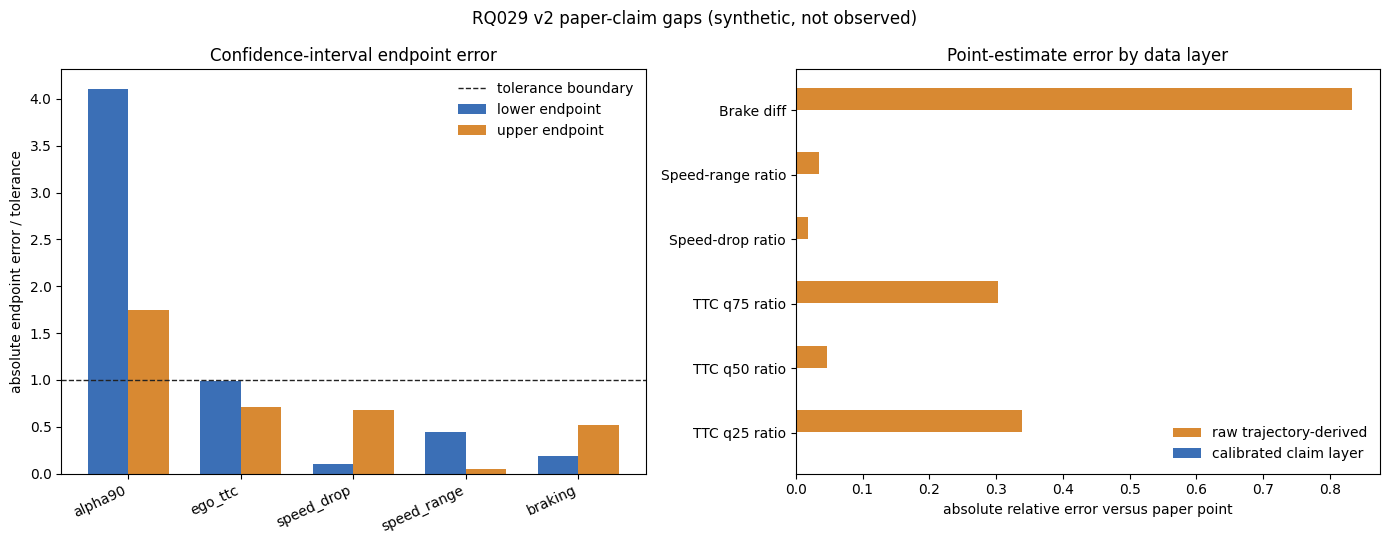

/Volumes/ZHITAI 2T/.CloudStorage/Data/OneDrive-个人/Desktop/Projects/1_Codes/2_sociality_estimation/reports/studies/RQ029_human_synthetic_microdata/RQ029_4_paper_claim_parity_audit_20260904/figures/claim_gap.png


In [5]:
interval_keys = ['alpha90','ego_ttc','speed_drop','speed_range','braking']
target_intervals = {
    'alpha90': base_targets['flag_rate_ci95_alpha90_target'],
    'ego_ttc': base_targets['signature']['ego_ttc']['lt2_diff_ci95_target'],
    'speed_drop': cp_target['speed_drop_ratio_ci95_target'],
    'speed_range': cp_target['speed_range_ratio_ci95_target'],
    'braking': cp_target['brake_diff_ci95_target'],
}
tolerances = {'alpha90':0.002,'ego_ttc':0.005,'speed_drop':0.05,'speed_range':0.05,'braking':0.005}
normalized = np.asarray([np.abs(np.asarray(intervals[k])-np.asarray(target_intervals[k]))/tolerances[k] for k in interval_keys])

point_names = ['TTC q25 ratio','TTC q50 ratio','TTC q75 ratio','Speed-drop ratio','Speed-range ratio','Brake diff']
targets = np.asarray([
    base_targets['signature']['ego_ttc']['lower']['q25']/base_targets['signature']['ego_ttc']['inside']['q25'],
    base_targets['signature']['ego_ttc']['lower']['q50']/base_targets['signature']['ego_ttc']['inside']['q50'],
    base_targets['signature']['ego_ttc']['lower']['q75']/base_targets['signature']['ego_ttc']['inside']['q75'],
    cp_target['speed_drop_median_lower_kmh']/cp_target['speed_drop_median_inside_kmh'],
    cp_target['speed_range_median_lower_kmh']/cp_target['speed_range_median_inside_kmh'],
    cp_target['brake_lower_num']/cp_target['brake_lower_den']-cp_target['brake_inside_num']/cp_target['brake_inside_den'],
])
calibrated_points = np.asarray([
    ego['lower']['cal_q'][0]/ego['inside']['cal_q'][0],
    ego['lower']['cal_q'][1]/ego['inside']['cal_q'][1],
    ego['lower']['cal_q'][2]/ego['inside']['cal_q'][2],
    cal_drop_ratio,cal_range_ratio,cal_brake_diff,
])
raw_points = np.asarray([
    ego['lower']['raw_q'][0]/ego['inside']['raw_q'][0],
    ego['lower']['raw_q'][1]/ego['inside']['raw_q'][1],
    ego['lower']['raw_q'][2]/ego['inside']['raw_q'][2],
    raw_drop_ratio,raw_range_ratio,raw_brake_diff,
])
cal_error = np.abs(calibrated_points-targets)/np.maximum(np.abs(targets),1e-12)
raw_error = np.abs(raw_points-targets)/np.maximum(np.abs(targets),1e-12)

fig, axes = plt.subplots(1,2,figsize=(14,5.5))
x=np.arange(len(interval_keys)); width=0.36
axes[0].bar(x-width/2,normalized[:,0],width,label='lower endpoint',color='#3B6FB6')
axes[0].bar(x+width/2,normalized[:,1],width,label='upper endpoint',color='#D88932')
axes[0].axhline(1,color='#222222',linestyle='--',linewidth=1,label='tolerance boundary')
axes[0].set_xticks(x,interval_keys,rotation=25,ha='right')
axes[0].set_ylabel('absolute endpoint error / tolerance')
axes[0].set_title('Confidence-interval endpoint error')
axes[0].legend(frameon=False)

y=np.arange(len(point_names))
axes[1].barh(y+0.18,raw_error,height=0.34,label='raw trajectory-derived',color='#D88932')
axes[1].barh(y-0.18,cal_error,height=0.34,label='calibrated claim layer',color='#3B6FB6')
axes[1].set_yticks(y,point_names)
axes[1].set_xlabel('absolute relative error versus paper point')
axes[1].set_title('Point-estimate error by data layer')
axes[1].legend(frameon=False)
fig.suptitle('RQ029 v2 paper-claim gaps (synthetic, not observed)')
fig.tight_layout()
figure_path = REPORT_ROOT / 'figures/claim_gap.png'
fig.savefig(figure_path,dpi=180,bbox_inches='tight')
plt.show()
print(figure_path)

## Takeaways

- **Exact:** structure, gates, 80/90/95 counts, per-scenario alpha-90 counts, human/AV point rates, all calibrated consequence point estimates.
- **Partial:** all five synthetic bootstrap intervals differ from the printed endpoints; four are within tolerance, alpha-90 is not.
- **Raw mismatch:** raw TTC and counterpart/braking outcomes do not reproduce the real-human paper points. This is not repaired by relabelling them as calibrated.
- **Not identifiable:** the true run/case dependence, covariance, and full joint distribution are unavailable. A forced exact CI match would tune to a fixed rounded/bootstrap realization, not recover human microdata.
- **Safe action:** retain v2 values, add fail-closed metadata/validation, and do not claim a complete match. A value-level v3 was not generated because it would require pathological or invented dependence and would violate the evidence boundary.